# v1 — метод затухания (gravity / distance-decay)

**Автор части:** Фёдор Кравченко

Вес ячейки — потенциал доступности к городам:

$$w_i = \sum_j \mathrm{pop}_j \cdot f(d_{ij}),$$

где $d_{ij}$ — расстояние от центроида ячейки $i$ до города $j$, $\mathrm{pop}_j$ —
население города, $f$ — ядро затухания. Затем региональная отгрузка $X$
разносится пропорционально $w_i$.

Что нового по сравнению с прежним `1/(d+1)`:
- вклад города взвешен его населением (Москва ≠ Балашиха на том же расстоянии);
- сравниваются три ядра — экспоненциальное, гауссово, степенное;
- масштаб ядра `sigma` подбирается по ранговой корреляции веса с растром
  населения WorldPop (`population` в сетке) как прокси истины.

**Зависимости:** сетки с признаками `data/processed/grid_*_1km_features.gpkg`
(колонки `population`, `dist_to_*_km`) готовятся в `02_grid.ipynb`.
Код метода: `src/spatial_decay.py`.


In [1]:
import os
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
# чтобы PROJ не ругался на пути к базе при работе с CRS
os.environ.setdefault("PROJ_DATA", str(Path(sys.executable).parents[1] / "share" / "proj"))

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "..")
from src import spatial_decay as sd

ROOT = Path("..")
PROC = ROOT / "data" / "processed"
RESULTS = ROOT / "results"

REGIONS = {
    "moscow":    dict(file="grid_moscow_1km_features.gpkg",        title="Московская область", border="border_mo.gpkg"),
    "krasnodar": dict(file="grid_krasnodar_1km_features.gpkg",     title="Краснодарский край", border="border_krasnodar.gpkg"),
    "yakutia":   dict(file="grid_yakutia_center_1km_features.gpkg", title="Якутия (центр)",     border="border_ya_center.gpkg"),
}
print("Регионов:", list(REGIONS))


Регионов: ['moscow', 'krasnodar', 'yakutia']


## 1. Загрузка сеток

In [2]:
grids = {}
for key, cfg in REGIONS.items():
    g = gpd.read_file(PROC / cfg["file"])
    grids[key] = g
    print(f"{cfg['title']:24s}  ячеек={len(g):>7,}  нас.>0={int((g['population']>0).sum()):>6,}")


Московская область        ячеек=141,967  нас.>0=48,815


Краснодарский край        ячеек=185,691  нас.>0=20,429


Якутия (центр)            ячеек=160,801  нас.>0= 3,061


## 2. Подбор `sigma` по корреляции с WorldPop

Для каждого региона и каждого ядра перебираем масштаб `sigma` и считаем
Spearman-корреляцию веса затухания с населением WorldPop. Берём `sigma` с
максимальной корреляцией.


In [3]:
SIGMA_GRID = {
    "exp":   [5, 10, 15, 20, 30, 40, 60, 80],
    "gauss": [5, 10, 15, 20, 30, 40, 60, 80],
    "power": [1.0, 1.5, 2.0, 2.5, 3.0, 4.0],
}

rows = []
for key, g in grids.items():
    Xr = sd.X_SHIPPING[key]
    for kind in sd.KERNELS:
        (best_sigma, rho), _ = sd.tune_sigma(g, key, kind, SIGMA_GRID[kind])
        v = sd.distribute_decay(g, Xr, key, best_sigma, kind)
        rows.append({
            "Регион": REGIONS[key]["title"],
            "region_key": key,
            "Ядро": kind,
            "sigma": best_sigma,
            "Spearman(WorldPop)": round(rho, 3),
            "Джини": round(sd.gini(v), 3),
            "Top-10%": round(sd.top_share(v), 3),
        })

kernels_df = pd.DataFrame(rows)
kernels_df


,Регион,region_key,Ядро,sigma,Spearman(WorldPop),Джини,Top-10%
0,Московская область,moscow,exp,30.0,0.445,0.755,0.613
1,Московская область,moscow,gauss,60.0,0.443,0.706,0.490
2,Московская область,moscow,power,2.0,0.447,0.596,0.510
3,Краснодарский край,krasnodar,exp,30.0,0.102,0.615,0.444
4,Краснодарский край,krasnodar,gauss,60.0,0.093,0.526,0.336
5,Краснодарский край,krasnodar,power,1.5,0.112,0.457,0.392
6,Якутия (центр),yakutia,exp,5.0,0.152,0.993,1.000
7,Якутия (центр),yakutia,gauss,5.0,0.154,0.998,1.000
8,Якутия (центр),yakutia,power,4.0,0.134,0.999,0.999


## 3. Расчёт v1

Используем **экспоненциальное** ядро во всех регионах: это стандартный выбор для
gravity-моделей доступности, а по корреляции с WorldPop оно лучшее или в пределах
шума по сравнению с gauss/power (см. таблицу выше). Единое ядро важнее, чем погоня
за сотыми долями шумной ранговой корреляции. `sigma` подбираем отдельно для каждого
региона. Результат пишем в колонку `method_otgr_v1`.


In [4]:
CHOSEN_KERNEL = "exp"

chosen = {}
metrics_rows = []
for key, g in grids.items():
    cfg = REGIONS[key]
    Xr = sd.X_SHIPPING[key]
    (sigma, rho), _ = sd.tune_sigma(g, key, CHOSEN_KERNEL, SIGMA_GRID[CHOSEN_KERNEL])

    v1 = sd.distribute_decay(g, Xr, key, sigma, CHOSEN_KERNEL)
    g["method_otgr_v1"] = v1
    chosen[key] = (CHOSEN_KERNEL, sigma)

    # прежний наивный вариант для сравнения: ближайший город, 1/(d+1), без населения
    d_min = sd.city_distances_km(g, sd.cities_gdf(key, g.crs)).min(axis=1)
    w_old = 1.0 / (d_min + 1.0)
    v_old = Xr * w_old / w_old.sum()
    g["method_otgr_v1_old"] = v_old

    metrics_rows.append({
        "Регион": cfg["title"], "region_key": key,
        "Ядро": CHOSEN_KERNEL, "sigma": sigma,
        "Spearman(WorldPop)": round(rho, 3),
        "Джини старый 1/(d+1)": round(sd.gini(v_old), 3),
        "Top-10% старый": round(sd.top_share(v_old), 3),
        "Джини v1": round(sd.gini(v1), 3),
        "Top-10% v1": round(sd.top_share(v1), 3),
    })

metrics_df = pd.DataFrame(metrics_rows)
print("Выбранные ядра (kind, sigma):", chosen)
metrics_df


Выбранные ядра (kind, sigma): {'moscow': ('exp', 30.0), 'krasnodar': ('exp', 30.0), 'yakutia': ('exp', 5.0)}


,Регион,region_key,Ядро,sigma,Spearman(WorldPop),Джини старый 1/(d+1),Top-10% старый,Джини v1,Top-10% v1
0,Московская область,moscow,exp,30.0,0.445,0.466,0.380,0.755,0.613
1,Краснодарский край,krasnodar,exp,30.0,0.102,0.390,0.329,0.615,0.444
2,Якутия (центр),yakutia,exp,5.0,0.152,0.385,0.329,0.993,1.000


## 4. Карты: старое `1/(d+1)` vs гравитационная модель

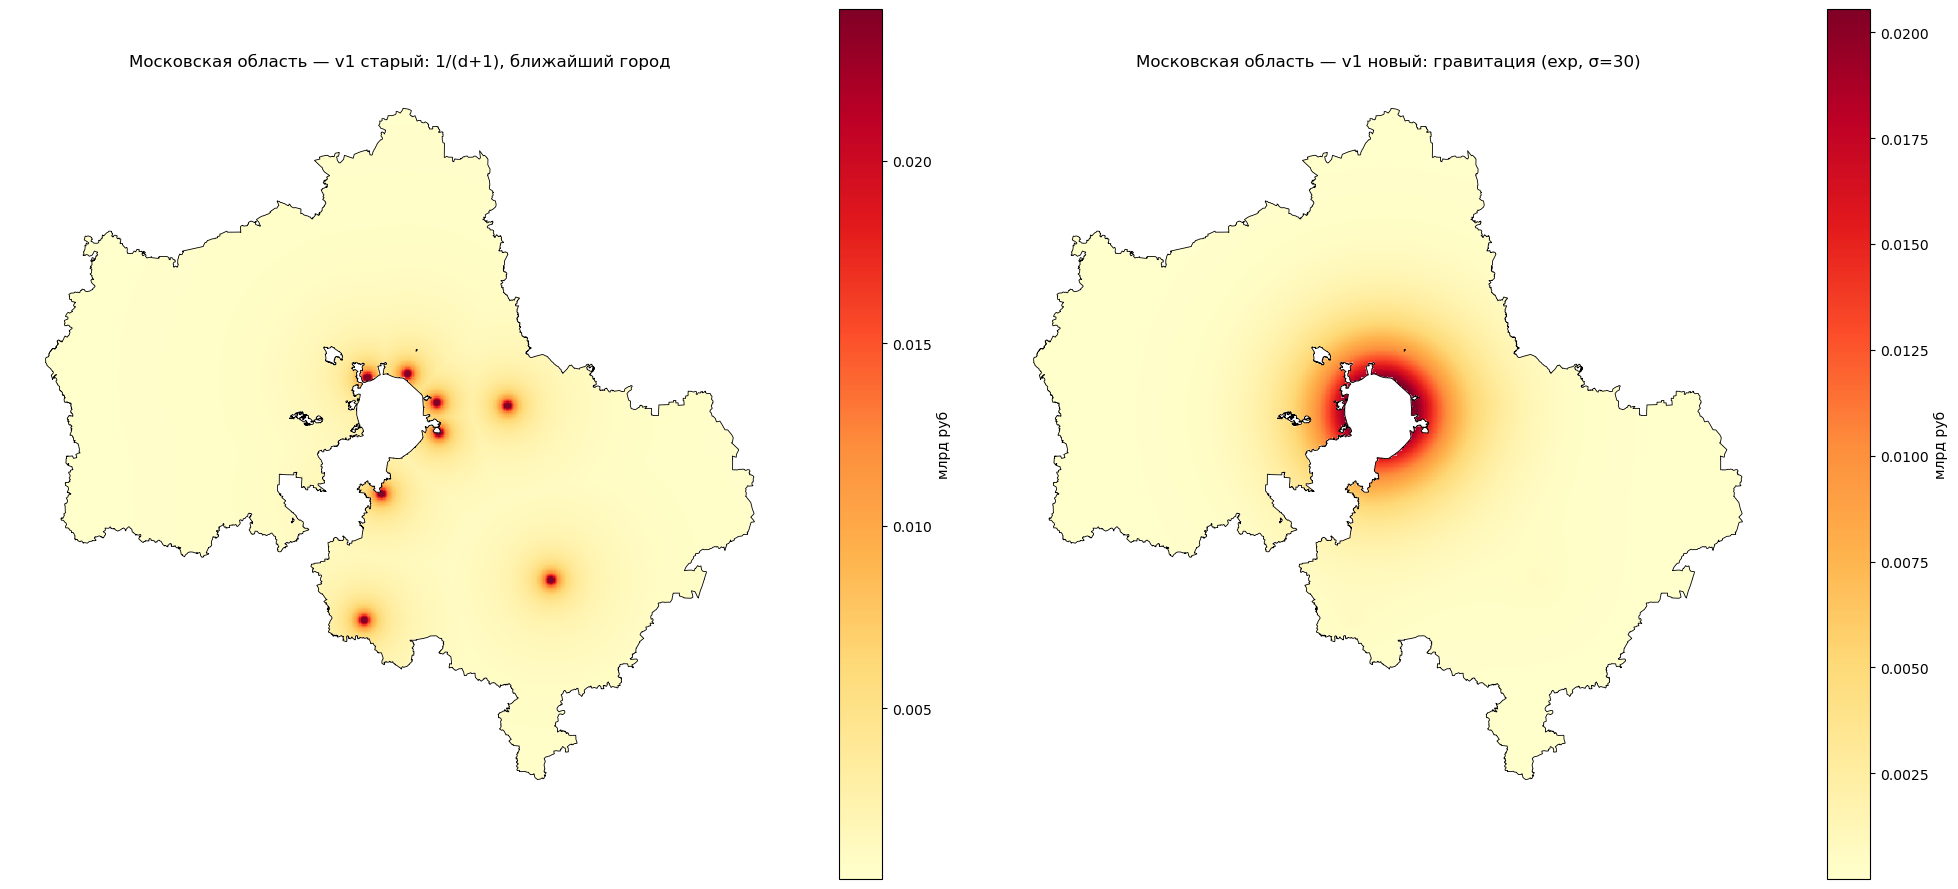

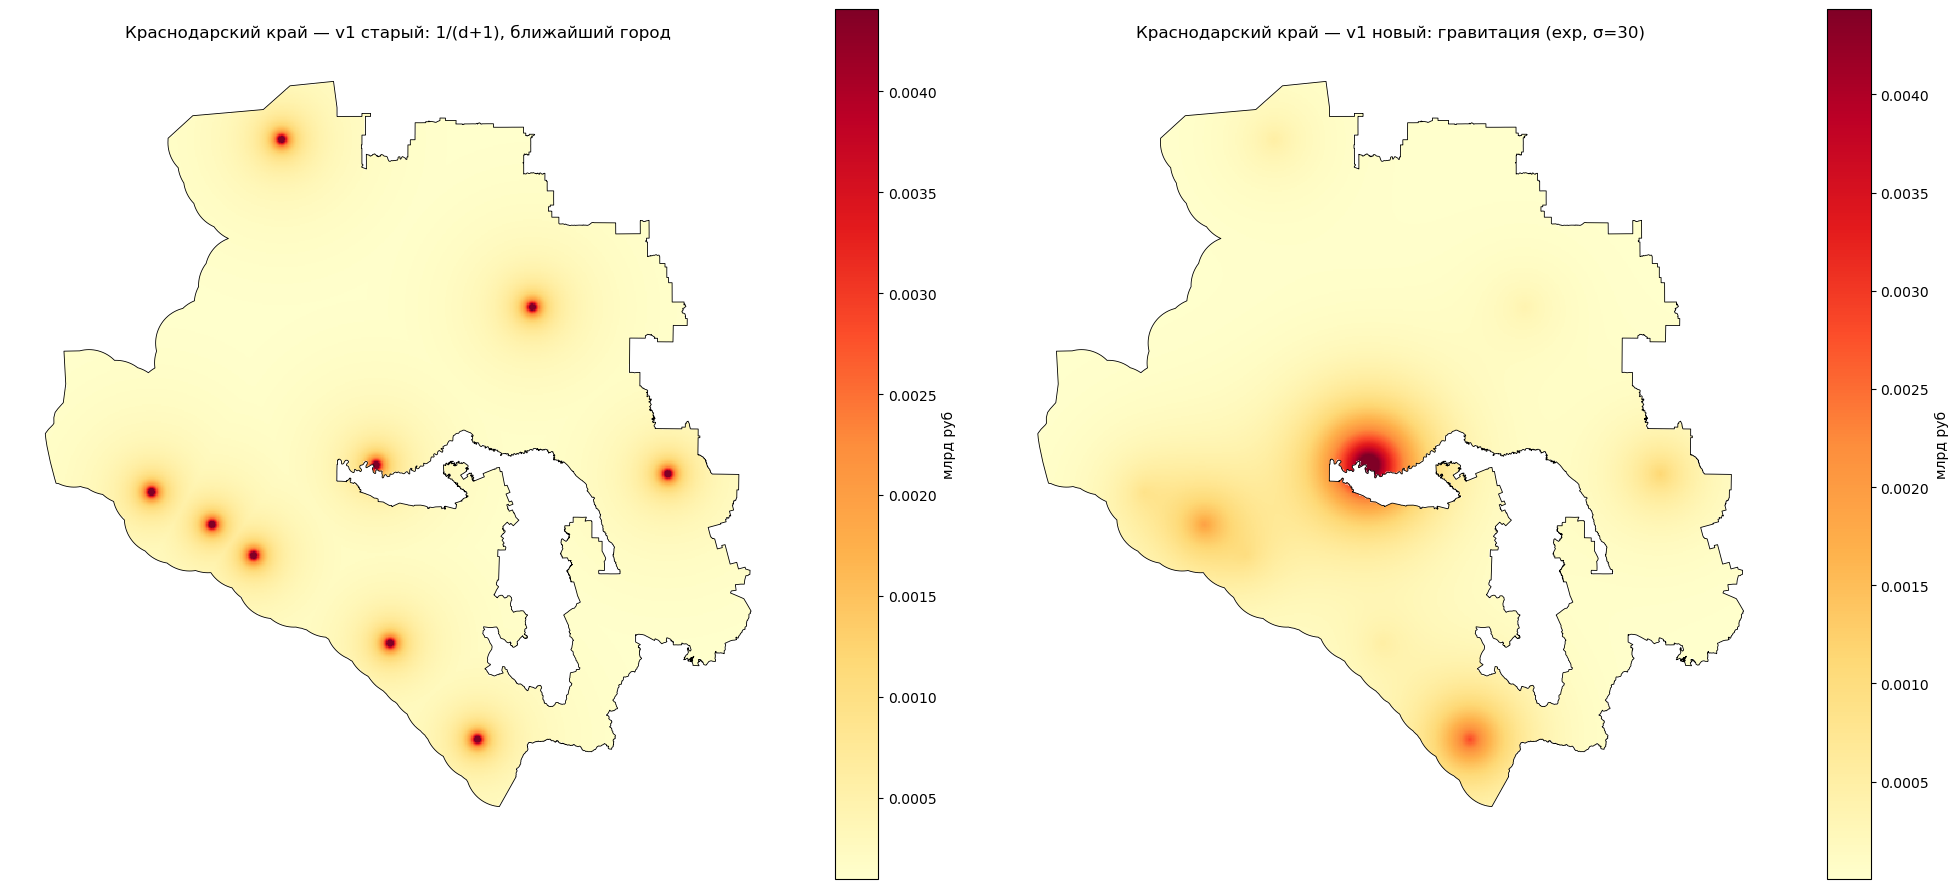

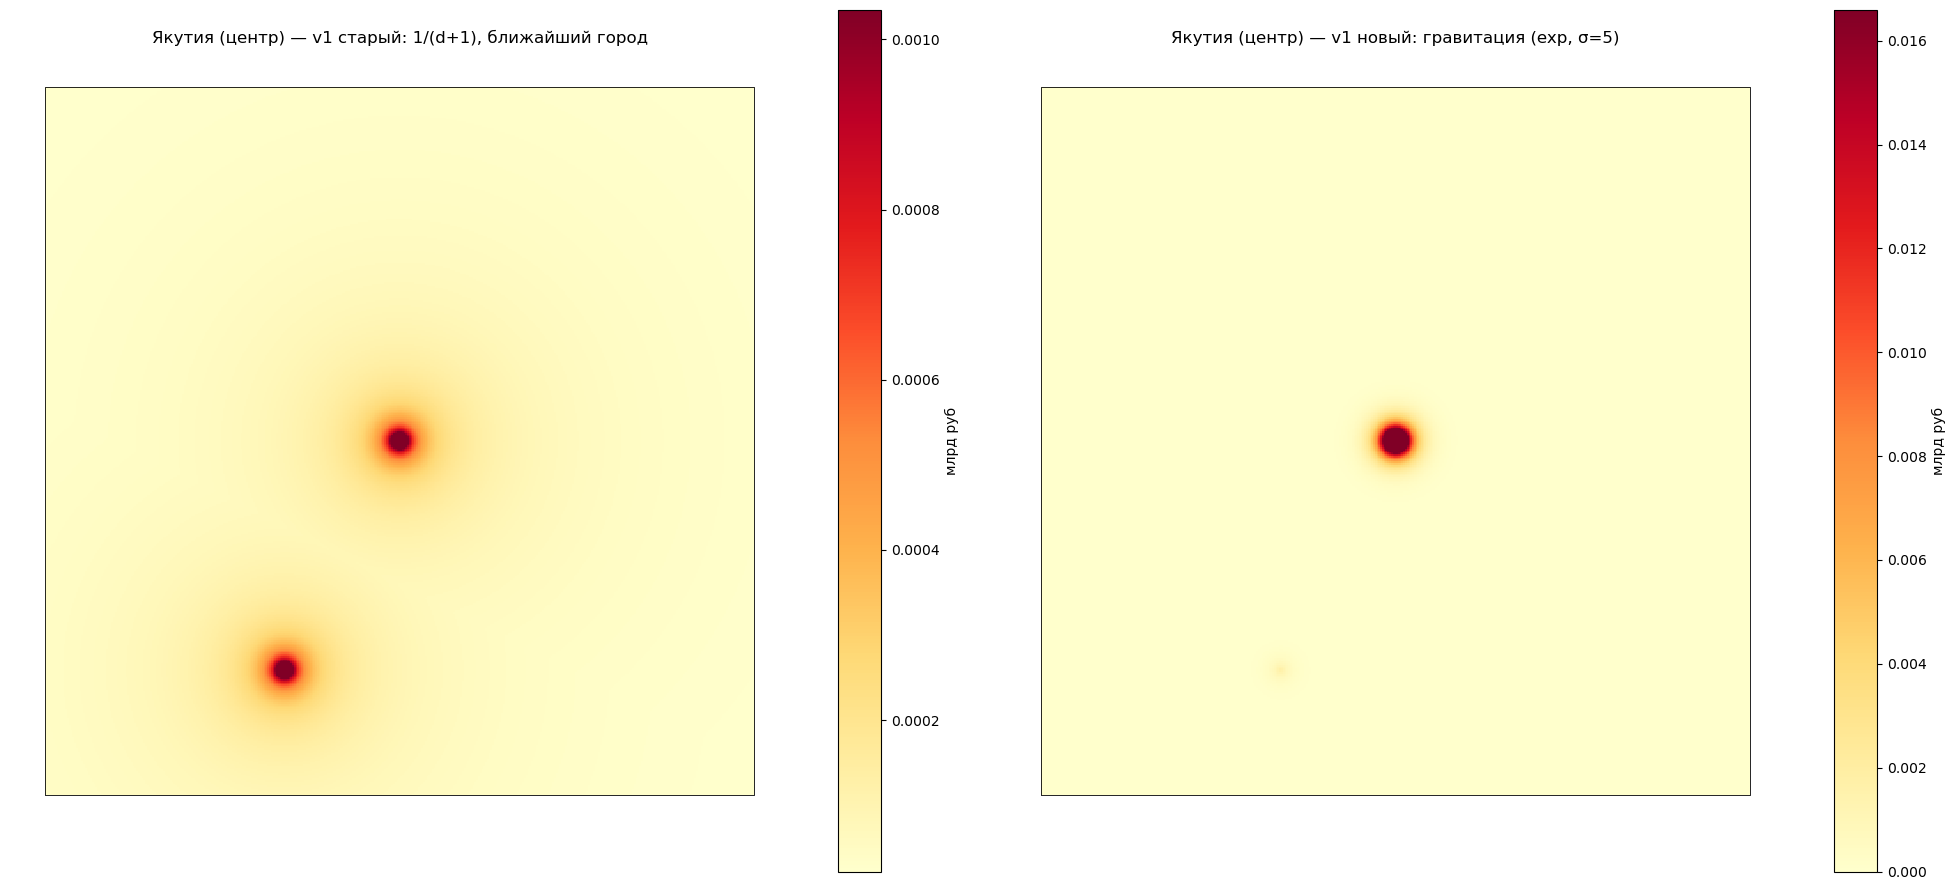

In [5]:
def plot_compare(key):
    g = grids[key]
    cfg = REGIONS[key]
    border = gpd.read_file(PROC / cfg["border"]).to_crs(g.crs)
    kind, sigma = chosen[key]

    fig, axes = plt.subplots(1, 2, figsize=(20, 9))
    for ax, col, title in [
        (axes[0], "method_otgr_v1_old", "v1 старый: 1/(d+1), ближайший город"),
        (axes[1], "method_otgr_v1",     f"v1 новый: гравитация ({kind}, σ={sigma:g})"),
    ]:
        g.plot(column=col, ax=ax, cmap="YlOrRd", legend=True,
               legend_kwds={"label": "млрд руб"},
               vmax=g[col].quantile(0.999), linewidth=0)
        border.boundary.plot(ax=ax, color="black", linewidth=0.6)
        ax.set_title(f"{cfg['title']} — {title}")
        ax.set_axis_off()
    fig.tight_layout()
    fig.savefig(RESULTS / f"decay_{key}.png", dpi=110, bbox_inches="tight")
    plt.show()

for key in REGIONS:
    plot_compare(key)


### Форма ядер затухания

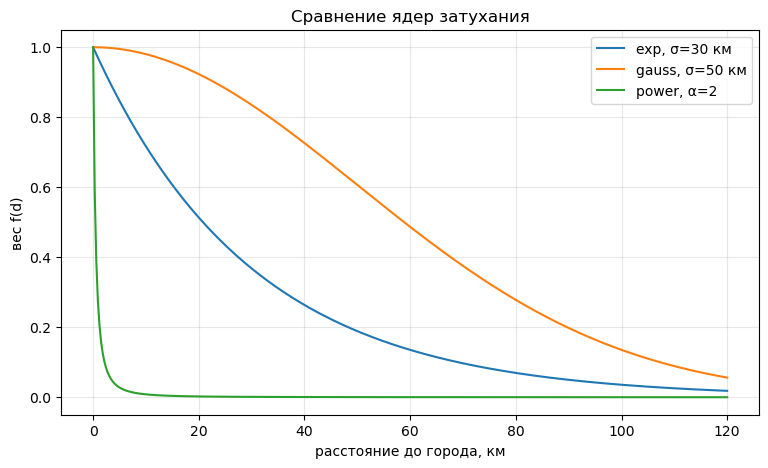

In [6]:
d = np.linspace(0, 120, 400)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(d, sd.decay_kernel(d, 30, "exp"),   label="exp, σ=30 км")
ax.plot(d, sd.decay_kernel(d, 50, "gauss"), label="gauss, σ=50 км")
ax.plot(d, sd.decay_kernel(d, 2.0, "power"), label="power, α=2")
ax.set_xlabel("расстояние до города, км")
ax.set_ylabel("вес f(d)")
ax.set_title("Сравнение ядер затухания")
ax.legend(); ax.grid(alpha=0.3)
fig.savefig(RESULTS / "decay_kernels_shape.png", dpi=110, bbox_inches="tight")
plt.show()


## 5. Сохранение артефактов

- `results/decay_kernels.csv` — полный перебор ядер × регионов;
- `results/decay_metrics.csv` — выбранный v1 и сравнение со старым `1/(d+1)`;
- `results/decay_grids/grid_*_v1.gpkg` — сетки с колонкой `method_otgr_v1`.


In [7]:
kernels_df.drop(columns=["region_key"]).to_csv(RESULTS / "decay_kernels.csv", index=False)
metrics_df.drop(columns=["region_key"]).to_csv(RESULTS / "decay_metrics.csv", index=False)

out_dir = RESULTS / "decay_grids"
out_dir.mkdir(exist_ok=True)
for key, g in grids.items():
    cols = ["cell_id", "geometry", "population", "method_otgr_v1"]
    g[cols].to_file(out_dir / f"grid_{key}_v1.gpkg", driver="GPKG")

print("Сохранено в", RESULTS)
print(metrics_df[["Регион", "Ядро", "sigma", "Джини v1", "Top-10% v1"]].to_string(index=False))


Сохранено в ../results
            Регион Ядро  sigma  Джини v1  Top-10% v1
Московская область  exp   30.0     0.755       0.613
Краснодарский край  exp   30.0     0.615       0.444
    Якутия (центр)  exp    5.0     0.993       1.000
